In [45]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

In [46]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "GarbageClassificationDataset/train",
    image_size=(224, 224),
    batch_size=32
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "GarbageClassificationDataset/val",
    image_size=(224, 224),
    batch_size=32
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "GarbageClassificationDataset/test",
    image_size=(224, 224),
    batch_size=32
)

Found 2527 files belonging to 6 classes.
Found 2527 files belonging to 6 classes.
Found 2527 files belonging to 6 classes.


In [47]:
class_names = train_ds.class_names
print(class_names)

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [48]:
from tensorflow.keras import layers

normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

In [2]:
from tensorflow.keras import models, layers

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),

    layers.Dense(6, activation='softmax')  
])

D:\Anacoda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [3]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [65]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50
)
import matplotlib.pyplot as plt

Epoch 1/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 55s 674ms/step - accuracy: 0.3296 - loss: 1.6976 - val_accuracy: 0.4448 - val_loss: 1.3545
Epoch 2/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 53s 666ms/step - accuracy: 0.5140 - loss: 1.2585 - val_accuracy: 0.6055 - val_loss: 1.0585
Epoch 3/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 52s 651ms/step - accuracy: 0.6154 - loss: 1.0272 - val_accuracy: 0.6696 - val_loss: 0.8709
Epoch 4/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 54s 682ms/step - accuracy: 0.6965 - loss: 0.8281 - val_accuracy: 0.7574 - val_loss: 0.6474
Epoch 5/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 54s 677ms/step - accuracy: 0.7705 - loss: 0.6333 - val_accuracy: 0.8623 - val_loss: 0.3908
Epoch 6/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 52s 655ms/step - accuracy: 0.8567 - loss: 0.4260 - val_accuracy: 0.8967 - val_loss: 0.3192
Epoch 7/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 52s 660ms/step - accuracy: 0.9038 - loss: 0.2885 - val_accuracy: 0.9418 - val_loss: 0.1759
Epoch 8/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 52s 661ms/step - accuracy: 0.9260 - loss: 0.2312 - val_accu

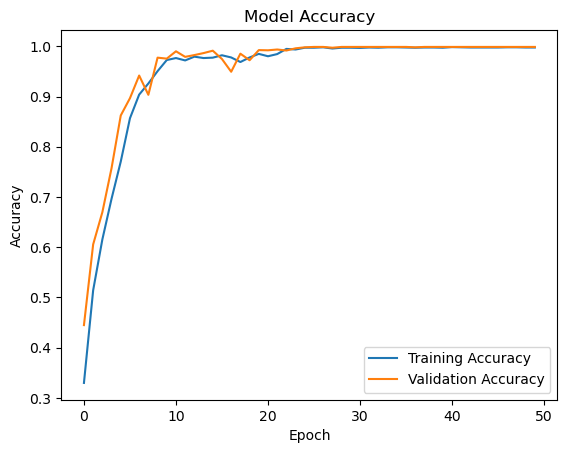

In [66]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Training Accuracy', 'Validation Accuracy'])

plt.show()

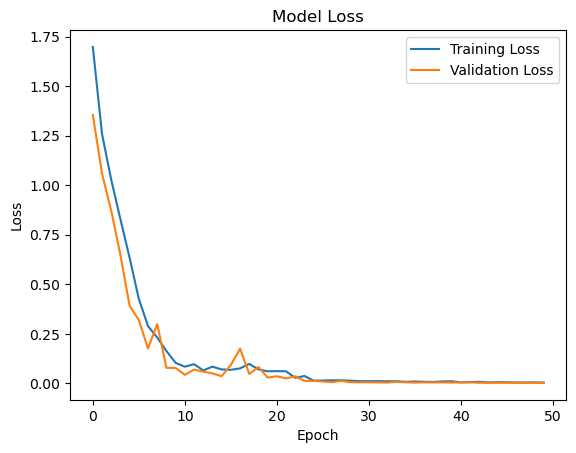

In [67]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Training Loss', 'Validation Loss'])

plt.show()

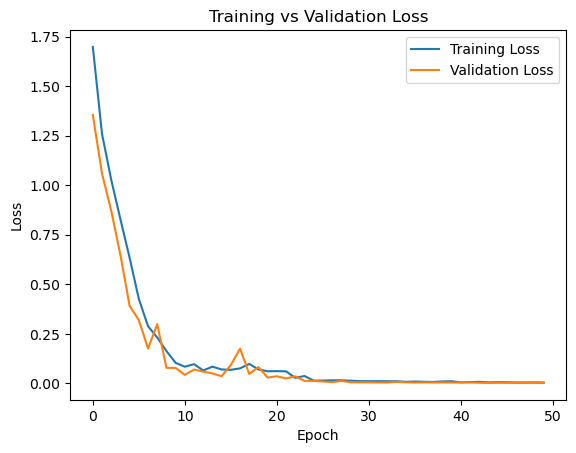

In [68]:


plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Training Loss', 'Validation Loss'])

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

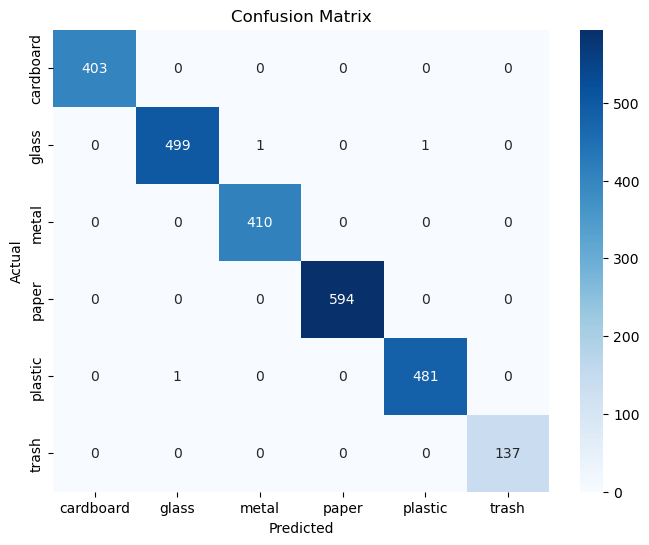

In [69]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_true = []
y_pred = []

for images, labels in test_ds:

    predictions = model.predict(images)

    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [56]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)

79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 115ms/step - accuracy: 0.9972 - loss: 0.0085
Test Accuracy: 0.9972299337387085


In [70]:
# model.save("garbage_modelep50.h5")

In [4]:
model = load_model("garbage_modelep35.h5")

NameError: name 'load_model' is not defined

In [17]:
class_names = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

In [35]:
# img_path = "cardboardtest1.jpg" 

# img = image.load_img(img_path, target_size=(224, 224))
# img_array = image.img_to_array(img)


# img_array = img_array / 255.0


# img_array = np.expand_dims(img_array, axis=0)



img_path = "papertest1.jpeg" 

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)


img_array = img_array / 255.0


img_array = np.expand_dims(img_array, axis=0)





# img_path = "plastictest1.jpeg" 

# img = image.load_img(img_path, target_size=(224, 224))
# img_array = image.img_to_array(img)


# img_array = img_array / 255.0


# img_array = np.expand_dims(img_array, axis=0)

In [36]:
prediction = model.predict(img_array)
class_index = np.argmax(prediction)

print("Predicted class:", class_names[class_index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
Predicted class: paper


In [1]:
!pip install opencv-python

   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
    --------------------------------------- 0.5/40.2 MB 2.4 MB/s eta 0:00:17
   - -------------------------------------- 1.0/40.2 MB 2.4 MB/s eta 0:00:17
   - -------------------------------------- 1.6/40.2 MB 2.4 MB/s eta 0:00:17
   -- ------------------------------------- 2.1/40.2 MB 2.3 MB/s eta 0:00:17
   -- ------------------------------------- 2.6/40.2 MB 2.3 MB/s eta 0:00:17
   -- ------------------------------------- 2.9/40.2 MB 2.3 MB/s eta 0:00:17
   --- ------------------------------------ 3.7/40.2 MB 2.3 MB/s eta 0:00:16
   --- ------------------------------------ 3.9/40.2 MB 2.3 MB/s eta 0:00:16
   ---- ----------------------------------- 4.5/40.2 MB 2.3 MB/s eta 0:00:16
   ---- ----------------------------------- 5.0/40.2 MB 2.3 MB/s eta 0:00:16
   ----- ---------------------------------- 5.5/40.2 MB 2.3 MB/s eta 0:00:15
   ----- ----

In [5]:
import cv2
import numpy as np
import time
from tensorflow.keras.models import load_model

model = load_model("garbage_model.h5")

class_names = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

cap = cv2.VideoCapture(0)

prediction_label = "Press S to Scan"

scanning = False
start_time = None

while True:

    ret, frame = cap.read()

    if not ret:
        break

    h, w, _ = frame.shape

   
    x1 = w//2 - 150
    y1 = h//2 - 150
    x2 = w//2 + 150
    y2 = h//2 + 150

    roi = frame[y1:y2, x1:x2]

   
    cv2.rectangle(frame, (x1,y1), (x2,y2), (0,255,0), 2)

   
    if scanning:

        elapsed = time.time() - start_time

        
        if elapsed >= 3:

            
            img = cv2.resize(roi, (224,224))

            
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            img_array = img / 255.0
            img_array = np.expand_dims(img_array, axis=0)

           
            prediction = model.predict(img_array, verbose=0)

            class_index = np.argmax(prediction)
            confidence = np.max(prediction)

            prediction_label = f"{class_names[class_index]} ({confidence*100:.1f}%)"

            
            scanning = False

        else:

            countdown = 3 - int(elapsed)
            prediction_label = f"Scanning in {countdown}..."

   
    cv2.putText(frame,
                prediction_label,
                (20,40),
                cv2.FONT_HERSHEY_SIMPLEX,
                1,
                (0,0,255),
                2)

    cv2.imshow("Garbage Classifier", frame)

    
    key = cv2.waitKey(1) & 0xFF

   
    if key == ord('s'):

        scanning = True
        start_time = time.time()
        prediction_label = "Hold Object Still..."

    
    elif key == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

In [59]:
from sklearn.metrics import classification_report
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

   cardboard       1.00      1.00      1.00       403
       glass       1.00      1.00      1.00       501
       metal       1.00      1.00      1.00       410
       paper       0.99      1.00      1.00       594
     plastic       1.00      0.99      1.00       482
       trash       1.00      1.00      1.00       137

    accuracy                           1.00      2527
   macro avg       1.00      1.00      1.00      2527
weighted avg       1.00      1.00      1.00      2527



In [60]:
from sklearn.metrics import confusion_matrix
import pandas as pd

cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

print(cm_df)

           cardboard  glass  metal  paper  plastic  trash
cardboard        401      0      0      2        0      0
glass              0    500      0      0        1      0
metal              0      1    409      0        0      0
paper              0      0      0    594        0      0
plastic            0      1      0      2      479      0
trash              0      0      0      0        0    137


In [ ]:
model.summary()